In [1]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt


files = sorted(glob.glob(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'UIEF', 
                                      'DOI-10-13012-b2idb-6955306_v2', 
                                      "*_WeatherStation_*.csv")))
dfs = []
for f in files:
    if 'NE_WeatherStation_2023' in f:
        df = pd.read_csv(f).iloc[2:, :]
    else:
        df = pd.read_csv(f, skiprows=1).iloc[2:, :]

    if 'NE_WeatherStation_2014' in f:
        df.drop(axis = 0, index = 14732, inplace = True) # data logger change?
    if 'NE_WeatherStation_2018' in f:
        df.drop(axis = 0, index = 4185, inplace = True) # data logger change?
    if 'NE_WeatherStation_2012' in f:
        df.drop(axis = 0, index = 13212, inplace = True) 
    if 'SE_WeatherStation_2015' in f:
        df.drop(axis = 0, index = 2153, inplace = True) # MISSING DATA : NOTE GAP IN DATA
    if 'SE_WeatherStation_2012' in f:
        df.drop(axis = 0, index = 13657, inplace = True)
    if 'CEN_WeatherStation_2014' in f:
        df.drop(axis = 0, index = [1258, 1259, 1260], inplace = True)

    df['TIMESTAMP'] = pd.DatetimeIndex(df['TIMESTAMP'])

    df.dropna(how = 'all', axis = 0, inplace = True)

    site = f.split('/')[-1].split('_')[0]
    df['site'] = site
 
    dfs.append(df)

result = pd.concat(dfs, axis = 0).set_index(['site', 'TIMESTAMP']).sort_index()
result = result.iloc[:, :-1].drop(['Battery','PanelTemp_Avg','RECORD','PanelTemp_Avg'], axis = 1)

# remove a string value
result = result.loc[result['AirTC_Avg'] != 'Avg', :].astype(float)

# Remove bad values
result.loc[result['AirTC_Avg'] <= -35, 'AirTC_Avg'] = np.nan
result.loc[result['AirTC_Avg'] >= 38, 'AirTC_Avg'] = np.nan
result.loc[result['AirTC_Avg'].diff().abs() >= 10, 'AirTC_Avg'] = np.nan
result.loc[(pd.DatetimeIndex(result.index.get_level_values(1)).month >= 7) & \
           (pd.DatetimeIndex(result.index.get_level_values(1)).month <= 10) & \
           (result['AirTC_Avg'] < -10), 'AirTC_Avg'] = np.nan
result.loc[result['RH1_Avg'] < 0, 'RH1_Avg'] = np.nan
# (this sensor's RH values have a problematic period)
result.loc[
    (pd.DatetimeIndex(result.index.get_level_values(1)).year >= 2017) & \
    (pd.DatetimeIndex(result.index.get_level_values(1)) <= pd.Timestamp('2022-04-01')) & \
    (result.index.get_level_values(0) == 'SE'), 'RH1_Avg'] = np.nan
# (filtering by max wind speed seems to better
#  identify the bad values)
result.loc[result['WindSpd_Max'] > 100, 'WindSpd_Avg'] = np.nan
result.loc[result['WindSpd_Avg'] > 20, 'WindSpd_Avg'] = np.nan
# (this site does not have wind speed measurements)
result.loc['CEN', 'WindSpd_Avg'] = np.nan
# 0.01 inch ie 100 = 1 inch => mm
result.loc[:, 'RAIN_Tot'] = result.loc[:, 'RAIN_Tot'].clip(lower = 0., upper = 100) * 0.01 * 25.4
result.loc[result['RAIN_Tot'] > 12.5, 'RAIN_Tot'] = np.nan

# Drop duplicate index
result = result.groupby(['site', 'TIMESTAMP']).mean()

# drop unused columns
result.drop(['WindSpd_Max', 'WindDir_Avg', 'PAR_APOGE_Avg'], axis = 1, inplace = True)

# Average to hourly
temp = []
for site in result.index.levels[0]:
    temp.append(result.loc[site].resample('1H').mean())
temp = pd.concat(temp, axis = 0, keys = result.index.levels[0])

# Accumulate rain (mm/hour)
temp['RAIN_Tot'] = temp['RAIN_Tot'] * 4

# Fix air pressure
temp2 = temp['PRESSURE_Avg'].unstack().T
temp2 = pd.Series(np.where(np.isnan(temp2['SE']), temp2['NE'], temp2['SE']), index = temp2.index)
for site in result.index.levels[0]:
    filt = temp2.index.intersection(temp.loc[site].index)
    temp.loc[(site, filt), 'PRESSURE_Avg'] = temp2.loc[filt].values

# Remove the year
temp = temp.loc[pd.DatetimeIndex(temp.index.get_level_values(1)).year >= 2010, :]

/tmp/ipykernel_521418/3864134385.py:78: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  temp.append(result.loc[site].resample('1H').mean())


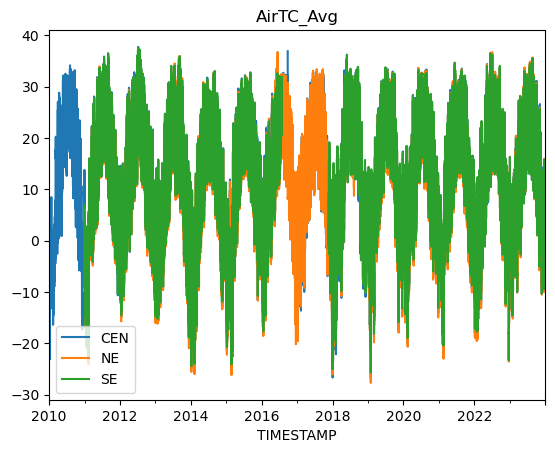

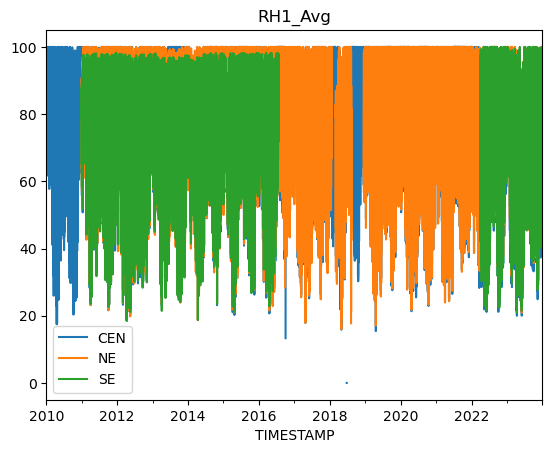

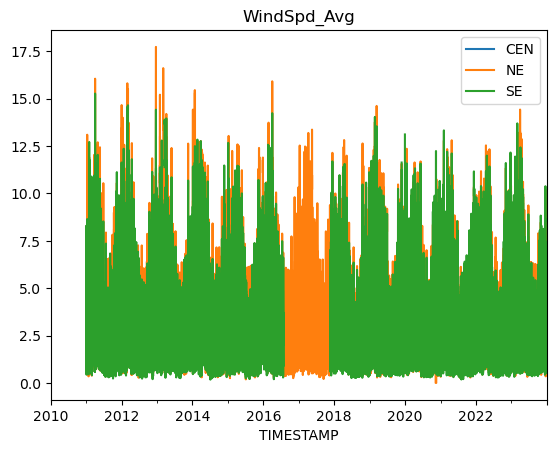

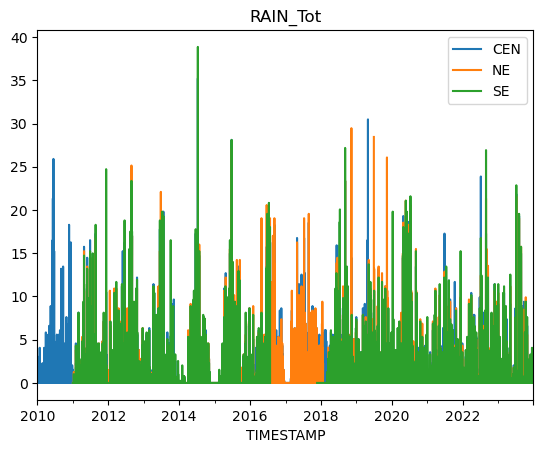

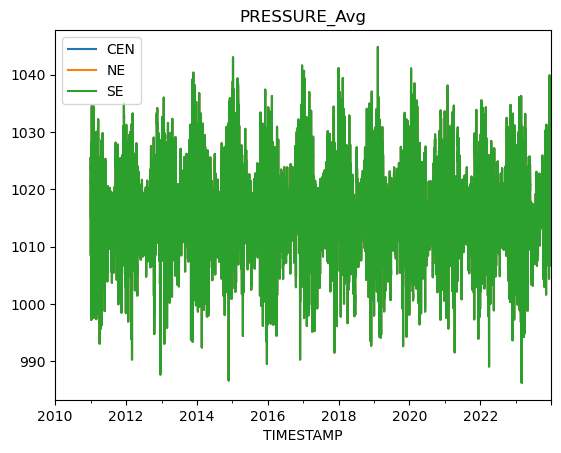

In [2]:
for col in temp.columns:
    plt.figure()
    for site in temp.index.levels[0]:
        temp.loc[site, col].plot(label = site)
    plt.legend()
    plt.title(col)

In [3]:
# average over three sites, expand NaN, and reassign
# wind speed and air pressure does not have value in 2010, otherwise the dataset is quite complete
result = temp.groupby('TIMESTAMP').mean().reindex(pd.date_range('2010-12-31 19:00:00', '2023-12-31 23:00:00', freq = '1H'))

# shift the hour of UTC-5 to observation
def shift_data(df, hours):
    df = df.copy()
    df.index = df.index + pd.Timedelta(hours = hours)
    return df

result = shift_data(result, 5)

# rotate the last five wind speed and pressure values to the first 5 values because
# they are not important
result.loc[result.index[:5], 'WindSpd_Avg'] = result.iloc[-5:, :]['WindSpd_Avg'].values
result.loc[result.index[:5], 'PRESSURE_Avg'] = result.iloc[-5:, :]['PRESSURE_Avg'].values

result = result.iloc[:-5, :]

/tmp/ipykernel_521418/2399701482.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  result = temp.groupby('TIMESTAMP').mean().reindex(pd.date_range('2010-12-31 19:00:00', '2023-12-31 23:00:00', freq = '1H'))


In [4]:
result

,AirTC_Avg,RH1_Avg,WindSpd_Avg,RAIN_Tot,PRESSURE_Avg
2011-01-01 00:00:00,12.177500,99.450000,4.439250,0.000,1018.77550
2011-01-01 01:00:00,12.160000,99.650000,6.139500,0.000,1019.29675
2011-01-01 02:00:00,12.115000,99.775000,6.280125,0.000,1019.74600
2011-01-01 03:00:00,12.017500,99.200000,5.382125,0.000,1020.15600
2011-01-01 04:00:00,11.172500,93.100000,5.359875,0.762,1020.74925
...,...,...,...,...,...
2023-12-31 19:00:00,0.322083,80.110000,5.783000,0.000,1015.57050
2023-12-31 20:00:00,0.190583,82.141667,5.602375,0.000,1016.31400
2023-12-31 21:00:00,-0.103000,85.591667,4.607000,0.000,1016.98300
2023-12-31 22:00:00,-0.233083,89.791667,5.110875,0.000,1017.56075


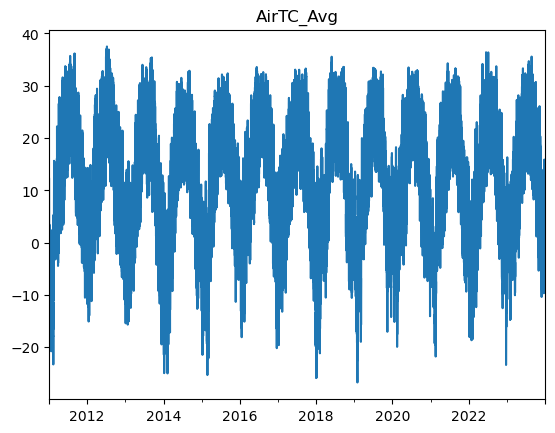

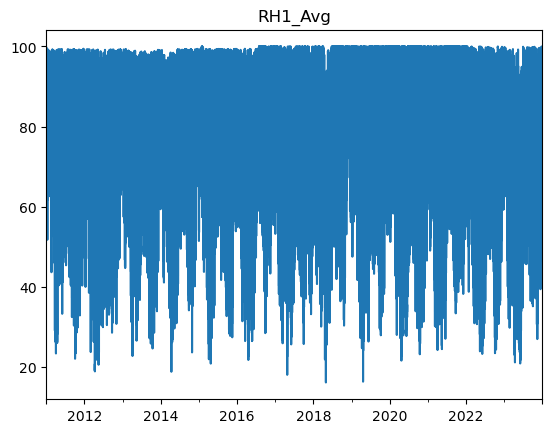

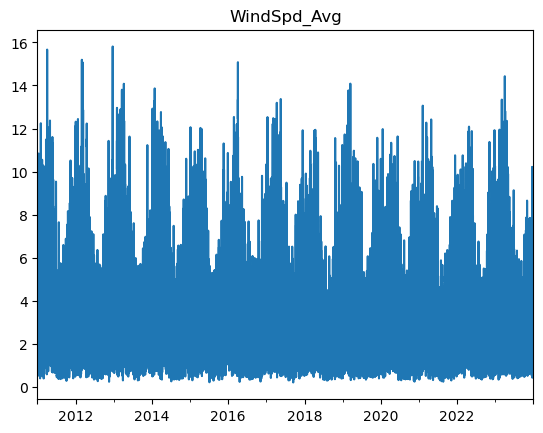

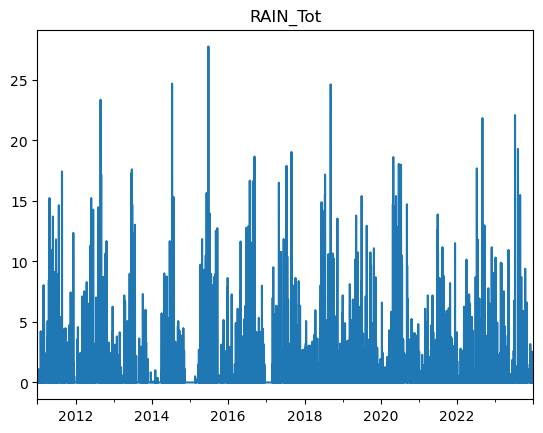

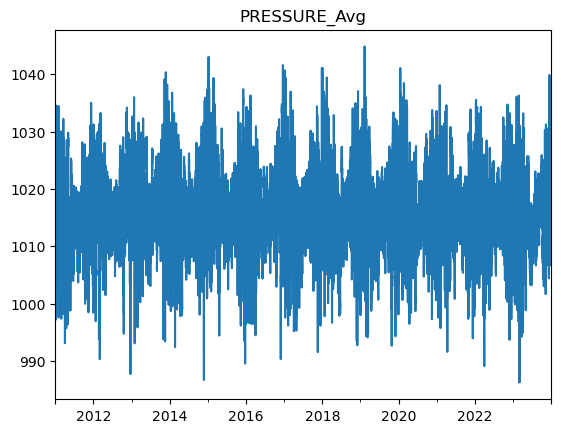

In [5]:
for col in result.columns:
    plt.figure()
    result[col].plot()
    plt.title(col)

In [6]:
result.isna().sum()

AirTC_Avg         0
RH1_Avg           0
WindSpd_Avg     266
RAIN_Tot          0
PRESSURE_Avg    170
dtype: int64

In [7]:
def find_nan_segments(pds):
    """ Identify the start and end datetime of the NaN values """
    mask = pds.isna()
    # Find changes in mask (True→False or False→True)
    changes = mask.ne(mask.shift()).cumsum()
    # Group by segment IDs, filter only NaN segments
    nan_segments = pds[mask].groupby(changes).apply(lambda x: (x.index[0], x.index[-1]))
    nan_segments = list(nan_segments)

    return nan_segments

nan_segments = {}
for var in ['WindSpd_Avg', 'PRESSURE_Avg']:
    nan_segments[var] = find_nan_segments(result[var])
    print('================' + var + '================')
    for row in nan_segments[var]:
        print(row)

================WindSpd_Avg================
(Timestamp('2012-05-22 11:00:00'), Timestamp('2012-05-29 12:00:00'))
(Timestamp('2013-01-13 07:00:00'), Timestamp('2013-01-13 23:00:00'))
(Timestamp('2013-03-19 18:00:00'), Timestamp('2013-03-19 21:00:00'))
(Timestamp('2014-01-30 17:00:00'), Timestamp('2014-01-30 17:00:00'))
(Timestamp('2014-02-17 18:00:00'), Timestamp('2014-02-18 00:00:00'))
(Timestamp('2018-02-21 09:00:00'), Timestamp('2018-02-21 19:00:00'))
(Timestamp('2019-02-24 11:00:00'), Timestamp('2019-02-24 11:00:00'))
(Timestamp('2021-01-01 14:00:00'), Timestamp('2021-01-02 02:00:00'))
(Timestamp('2021-01-26 06:00:00'), Timestamp('2021-01-26 17:00:00'))
(Timestamp('2021-01-27 09:00:00'), Timestamp('2021-01-27 10:00:00'))
(Timestamp('2021-03-15 16:00:00'), Timestamp('2021-03-15 16:00:00'))
(Timestamp('2022-02-02 10:00:00'), Timestamp('2022-02-02 18:00:00'))
(Timestamp('2022-02-17 17:00:00'), Timestamp('2022-02-18 10:00:00'))
================PRESSURE_Avg================
(Timestamp('20

In [8]:
# For the multi-day missing value between 2012-05-22 and 2012-05-19,
# replace with the average of the previous and next year
for var in ['WindSpd_Avg', 'PRESSURE_Avg']:
    temp_segment = nan_segments[var][0]

    result.loc[(result.index >= temp_segment[0]) & (result.index <= temp_segment[1]), var] = \
        0.5 * \
        (result.loc[(result.index >= temp_segment[0] - pd.Timedelta(days = 365)) & \
                    (result.index <= temp_segment[1] - pd.Timedelta(days = 365)), var].values + \
         result.loc[(result.index >= temp_segment[0] + pd.Timedelta(days = 365)) & \
                    (result.index <= temp_segment[1] + pd.Timedelta(days = 365)), var].values)

# for the remaining missing values, which are < 24 hours,
# replace with the average of the previous and next day
var = 'WindSpd_Avg'
for temp_segment in nan_segments[var][1:]:
    result.loc[(result.index >= temp_segment[0]) & (result.index <= temp_segment[1]), var] = \
        0.5 * \
        (result.loc[(result.index >= temp_segment[0] - pd.Timedelta(hours = 24)) & \
                    (result.index <= temp_segment[1] - pd.Timedelta(hours = 24)), var].values + \
         result.loc[(result.index >= temp_segment[0] + pd.Timedelta(hours = 24)) & \
                    (result.index <= temp_segment[1] + pd.Timedelta(hours = 24)), var].values)


In [9]:
# Obtain short- and long-wave radiation from ERA5-Land
srds = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'UIEF',
                                'UIEF_surface_solar_radiation_downwards_hourly.csv'),
                   index_col = 0, parse_dates = True)
lrds = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'UIEF',
                                'UIEF_surface_thermal_radiation_downwards_hourly.csv'),
                   index_col = 0, parse_dates = True)

radiation = pd.concat([srds, lrds], axis = 1)

# rename the columns
radiation.columns = ['SRDS','FLDS']

# convert from J m-2 s-1 to W m-2
radiation /= 3600

In [11]:
# Concatenate the ERA5-Land and site data
result = pd.concat([result, radiation], axis = 1, join = 'inner')

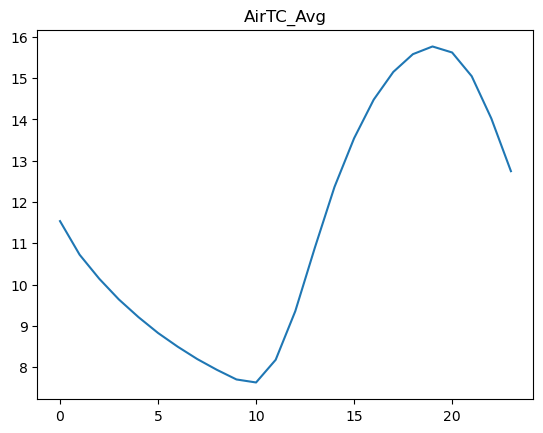

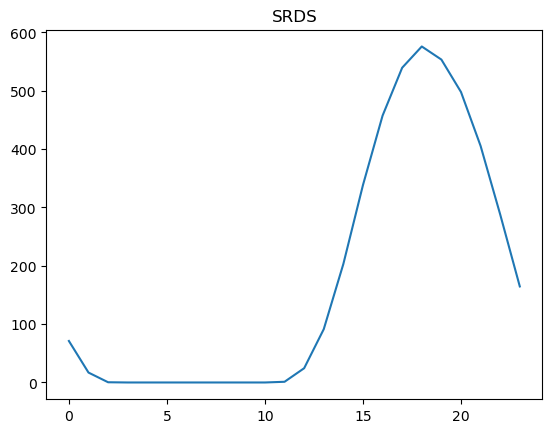

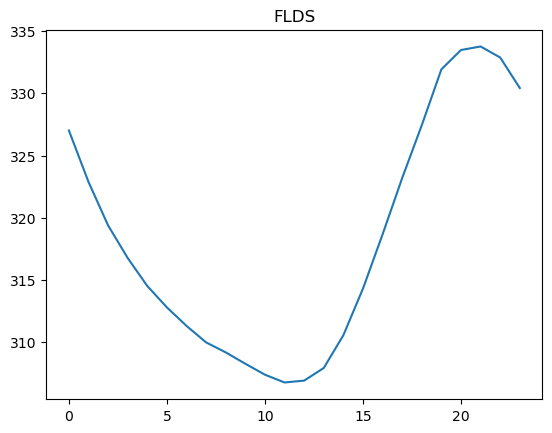

In [12]:
# Check the diurnal cycle
diurnal_cycle = result.groupby(result.index.hour).mean()

for col in ['AirTC_Avg', 'SRDS', 'FLDS']:
    plt.figure()
    diurnal_cycle[col].plot()
    plt.title(col)

# Save to CSV
result.to_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'UIEF_metdata.csv'))